In [2]:
import pandas as pd


df = pd.read_excel("C:/Users/POOJA/Downloads/cleaned data.xlsx", skiprows=1)


print(df.columns.tolist())



['Unnamed: 0', 'Last Price', 'News Sentiment - Daily Average', 'Last Price.1', 'News Sentiment - Daily Average.1', 'Last Price.2', 'News Sentiment - Daily Average.2', 'Last Price (USD)', 'Last Price.3', 'News Sentiment - Daily Average.3', 'Last Price (USD).1', 'Last Price.4', 'News Sentiment - Daily Average.4', 'Last Price (USD).2', 'Last Price.5', 'News Sentiment - Daily Average.5', 'Last Price (USD).3', 'Last Price.6', 'News Sentiment - Daily Average.6', 'Last Price (USD).4', 'Unnamed: 20', 'Last Price.7', 'Last Price.8', 'Last Price.9', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29']


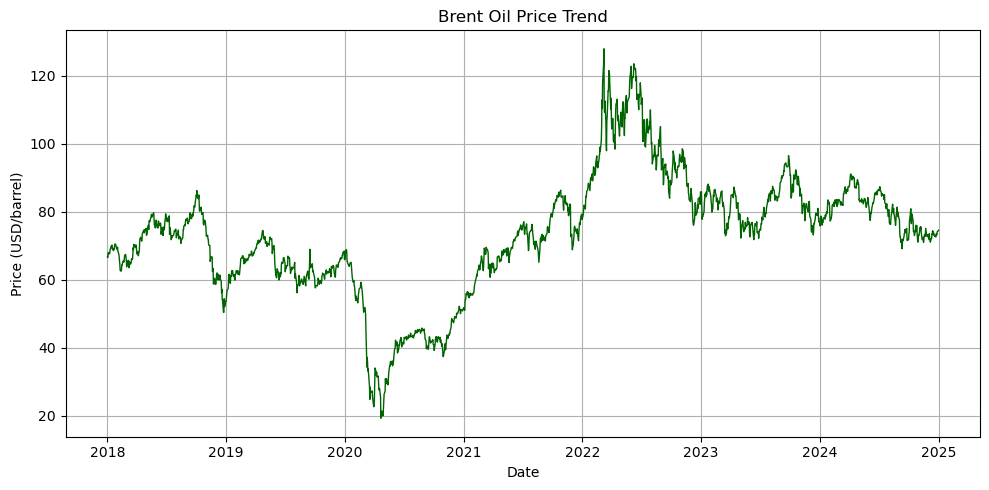

In [4]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_excel("C:/Users/POOJA/Downloads/cleaned data.xlsx")


df.rename(columns={
    'Unnamed: 0': 'Date',
    'CO1 Comdty': 'Brent'  # if this exists in your original data
}, inplace=True)


df['Date'] = pd.to_datetime(df['Date'], format="%Y-%m-%d", errors='coerce')

df['Brent'] = pd.to_numeric(df['Brent'], errors='coerce')


df_clean = df.dropna(subset=['Date', 'Brent'])


plt.figure(figsize=(10,5))
plt.plot(df_clean['Date'], df_clean['Brent'], color='darkgreen', linewidth=1)
plt.title("Brent Oil Price Trend")
plt.xlabel("Date")
plt.ylabel("Price (USD/barrel)")
plt.grid(True)
plt.tight_layout()
plt.show()


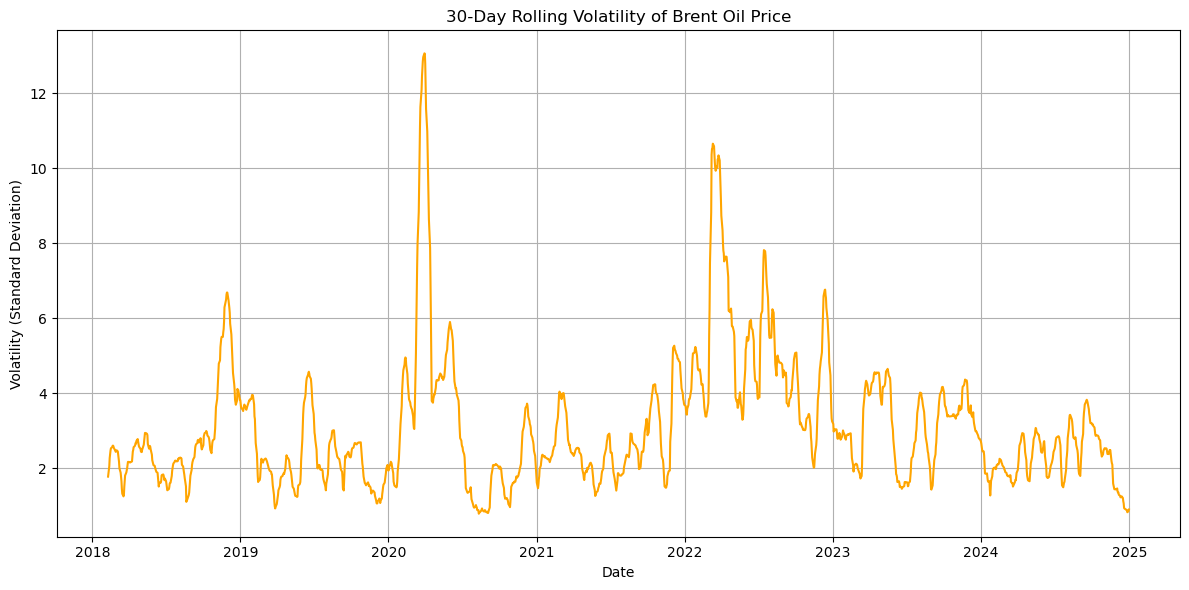

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 30-day rolling standard deviation
df['Rolling_Volatility'] = df['Brent'].rolling(window=30).std()

# Plotting
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Rolling_Volatility'], color='orange', linewidth=1.5)
plt.title('30-Day Rolling Volatility of Brent Oil Price')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation)')
plt.grid(True)
plt.tight_layout()
plt.show()


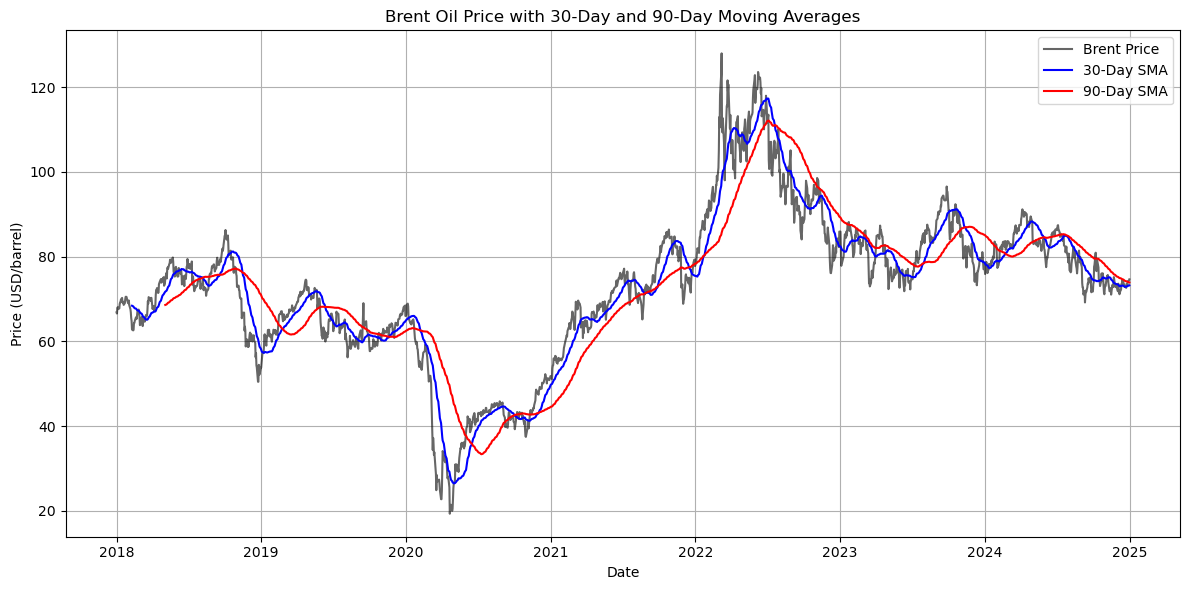

In [13]:
# Calculate Moving Averages
df['SMA_30'] = df['Brent'].rolling(window=30).mean()
df['SMA_90'] = df['Brent'].rolling(window=90).mean()

# Plot
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Brent'], label='Brent Price', color='black', alpha=0.6)
plt.plot(df['Date'], df['SMA_30'], label='30-Day SMA', color='blue', linewidth=1.5)
plt.plot(df['Date'], df['SMA_90'], label='90-Day SMA', color='red', linewidth=1.5)
plt.title('Brent Oil Price with 30-Day and 90-Day Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD/barrel)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


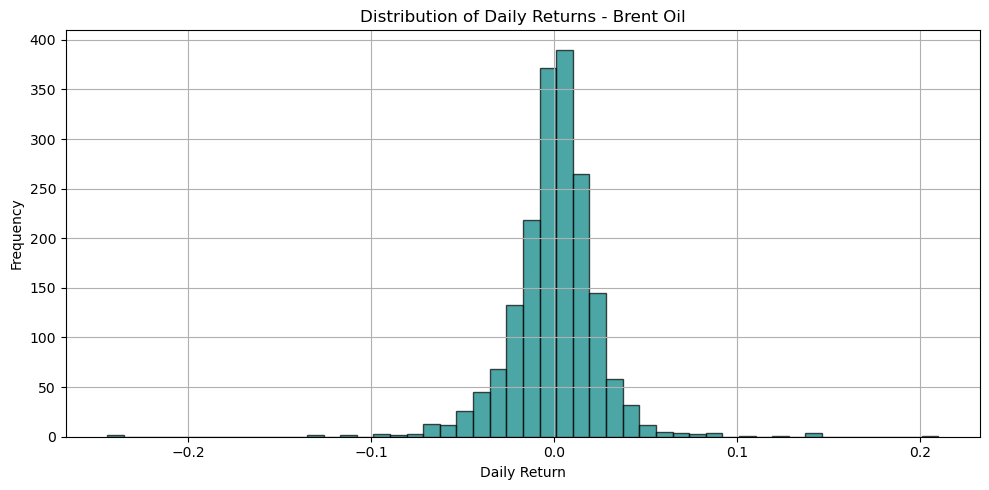

In [6]:

df['daily_return'] = df['Brent'].pct_change()


df_returns = df['daily_return'].dropna()


plt.figure(figsize=(10,5))
plt.hist(df_returns, bins=50, color='teal', edgecolor='black', alpha=0.7)
plt.title('Distribution of Daily Returns - Brent Oil')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


In [34]:
pip install statsmodels


C:\Users\POOJA\AppData\Local\Temp\ipykernel_41968\515901671.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
C:\Users\POOJA\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


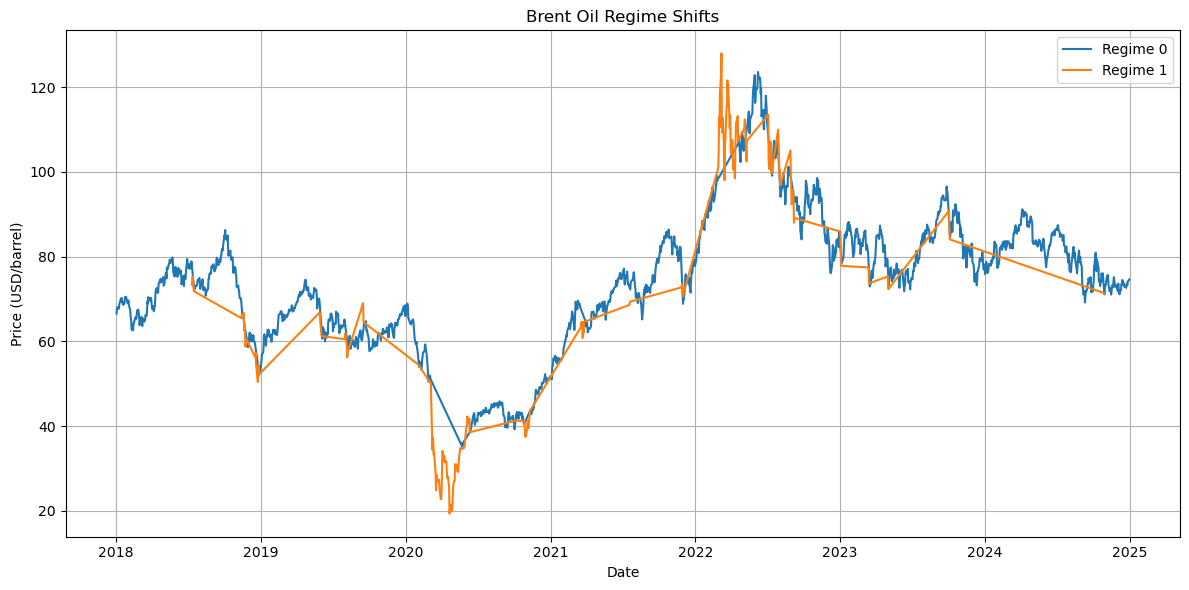

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# Load the data
df = pd.read_excel("cleaned data.xlsx")


df.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)


df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['CO1 Comdty'] = pd.to_numeric(df['CO1 Comdty'], errors='coerce')

df.replace([np.inf, -np.inf], np.nan, inplace=True)


df['log_return'] = np.log(df['CO1 Comdty'] / df['CO1 Comdty'].shift(1))


df.dropna(subset=['Date', 'CO1 Comdty', 'log_return'], inplace=True)

# Set Date as index
df.set_index('Date', inplace=True)

# Fit Markov Switching Model
model = MarkovRegression(df['log_return'], k_regimes=2, trend='c', switching_variance=True)
result = model.fit()

# Assign most probable regime
df['regime'] = result.smoothed_marginal_probabilities.idxmax(axis=1)

# Plot regimes
plt.figure(figsize=(12, 6))
for regime in sorted(df['regime'].unique()):
    plt.plot(df.index[df['regime'] == regime],
             df['CO1 Comdty'][df['regime'] == regime],
             label=f'Regime {regime}')

plt.title('Brent Oil Regime Shifts')
plt.xlabel('Date')
plt.ylabel('Price (USD/barrel)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\POOJA\AppData\Local\Temp\ipykernel_35172\136918262.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
C:\Users\POOJA\AppData\Local\Temp\ipykernel_35172\136918262.py:37: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Brent_ret'] = df[brent_col].pct_change()
C:\Users\POOJA\AppData\Local\Temp\ipykernel_35172\136918262.py:54: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[bench_ret] = df[wt

==== Static Beta (OLS) ====
Benchmark used: WTI/CL1
Alpha: 0.00059   Beta: 0.141   R^2: 0.216



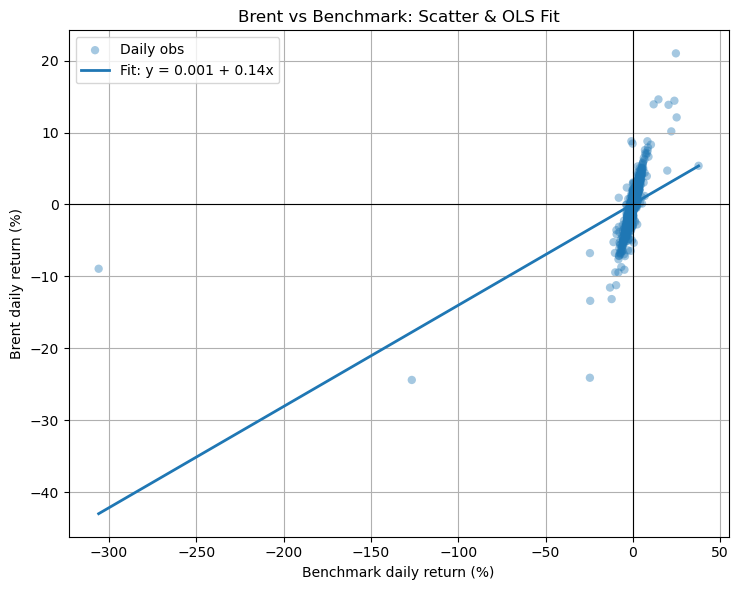

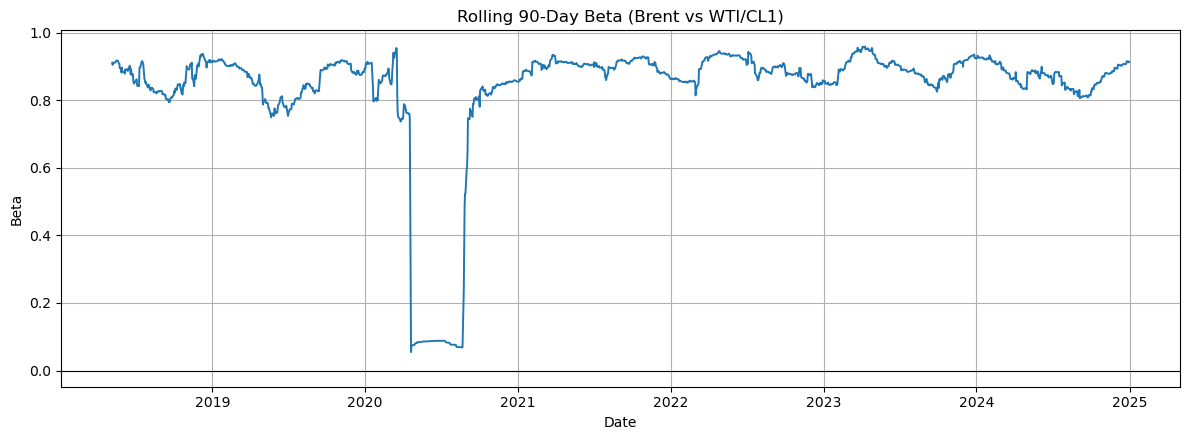

==== Multi-factor Sensitivity (Brent returns) ====
                            OLS Regression Results                            
Dep. Variable:              Brent_ret   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     250.6
Date:                Mon, 18 Aug 2025   Prob (F-statistic):           6.84e-97
Time:                        22:49:27   Log-Likelihood:                 4351.4
No. Observations:                1826   AIC:                            -8697.
Df Residuals:                    1823   BIC:                            -8680.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

C:\Users\POOJA\AppData\Local\Temp\ipykernel_35172\136918262.py:116: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  factors['WTI_ret'] = df[wti_col].pct_change()


In [50]:
# ----- Beta & Sensitivity (auto-detect columns) -----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1) Load & clean
df = pd.read_excel("cleaned data.xlsx")
df.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)        # if your date col is unnamed
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# 2) Identify columns we can use
candidates_brent = ['CO1 Comdty', 'Brent', 'Brent (CO1)']
candidates_wti   = ['CL1 Comdty', 'WTI Comdty', 'WTI']
candidates_fx    = ['EURUSD Curncy', 'EURUSD', 'EURUSD CURNCY']  # USD proxy (we'll invert)

def first_col(cols):
    for c in cols:
        if c in df.columns:
            return c
    return None

brent_col = first_col(candidates_brent)
wti_col   = first_col(candidates_wti)
eurusd    = first_col(candidates_fx)

assert brent_col is not None, f"Brent column not found. Saw: {df.columns.tolist()}"

# 3) Make numeric
for c in [brent_col, wti_col, eurusd]:
    if c and c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# 4) Build returns
df = df.sort_values('Date').set_index('Date')
df['Brent_ret'] = df[brent_col].pct_change()

# choose the benchmark we actually have
bench_name = None
if wti_col:
    bench_name = wti_col                          # closest physical substitute
elif eurusd:
    bench_name = eurusd + " (inv)"                # use inverse EURUSD as USD strength proxy
    df['USD_proxy'] = -pd.Series(np.log(df[eurusd])).diff()  # inverse log return: USD ↑ → oil ↓ typically
else:
    raise ValueError("No suitable benchmark found (WTI/CL1 or EURUSD).")

if bench_name.endswith("(inv)"):
    bench_ret = 'USD_proxy'
else:
    df[wti_col] = pd.to_numeric(df[wti_col], errors='coerce')
    bench_ret = 'Bench_ret'
    df[bench_ret] = df[wti_col].pct_change()

# Align data
use_cols = ['Brent_ret']
if bench_ret not in df.columns:
    # if using USD proxy path, bench_ret == 'USD_proxy' already exists
    pass
use_cols.append(bench_ret)
df_beta = df[use_cols].dropna().copy()

# 5) OLS beta (Brent on benchmark)
X = sm.add_constant(df_beta[bench_ret])
y = df_beta['Brent_ret']
ols = sm.OLS(y, X).fit()

beta = ols.params[bench_ret]
alpha = ols.params['const']
r2 = ols.rsquared

print("==== Static Beta (OLS) ====")
print(f"Benchmark used: {'WTI/CL1' if bench_ret=='Bench_ret' else 'USD (inverse EURUSD)'}")
print(f"Alpha: {alpha:.5f}   Beta: {beta:.3f}   R^2: {r2:.3f}\n")

# 6) Scatter + regression line
plt.figure(figsize=(7.5,6))
plt.scatter(df_beta[bench_ret]*100, df_beta['Brent_ret']*100, alpha=0.4, edgecolor='none', label='Daily obs')
x_line = np.linspace(df_beta[bench_ret].min(), df_beta[bench_ret].max(), 200)
y_line = alpha + beta*x_line
plt.plot(x_line*100, y_line*100, lw=2, label=f'Fit: y = {alpha:.3f} + {beta:.2f}x')
plt.axhline(0, color='k', lw=0.8); plt.axvline(0, color='k', lw=0.8)
plt.title('Brent vs Benchmark: Scatter & OLS Fit')
plt.xlabel(f"Benchmark daily return (%)")
plt.ylabel("Brent daily return (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 7) Rolling 90-day beta
win = 90
def rolling_beta(y, x, window=90):
    # cov(y,x)/var(x) in rolling window
    cov = (y.rolling(window).mean()*0)  # just a holder
    cov = (y.rolling(window).cov(x))
    var = x.rolling(window).var()
    return cov/var

roll_beta = rolling_beta(df_beta['Brent_ret'], df_beta[bench_ret], window=win)
plt.figure(figsize=(12,4.5))
plt.plot(roll_beta.index, roll_beta, lw=1.4)
plt.title(f'Rolling {win}-Day Beta (Brent vs {"WTI/CL1" if bench_ret=="Bench_ret" else "USD proxy"})')
plt.ylabel('Beta')
plt.xlabel('Date')
plt.axhline(0, color='k', lw=0.8)
plt.grid(True); plt.tight_layout(); plt.show()

# 8) OPTIONAL: multi-factor sensitivity if we have extra factors
has_multifactor = False
factors = pd.DataFrame(index=df.index)
factors['Brent_ret'] = df['Brent_ret']

if wti_col:
    factors['WTI_ret'] = df[wti_col].pct_change()
if eurusd:
    factors['USD_inv_ret'] = -pd.Series(np.log(df[eurusd])).diff()

# keep only available factor columns
factor_cols = [c for c in ['WTI_ret', 'USD_inv_ret'] if c in factors.columns]
if factor_cols:
    has_multifactor = True
    mf = factors[['Brent_ret'] + factor_cols].dropna()
    X_mf = sm.add_constant(mf[factor_cols])
    y_mf = mf['Brent_ret']
    mf_ols = sm.OLS(y_mf, X_mf).fit()
    print("==== Multi-factor Sensitivity (Brent returns) ====")
    print(mf_ols.summary())
else:
    print("No additional factors found for multi-factor regression (optional step skipped).")


C:\Users\POOJA\AppData\Local\Temp\ipykernel_34852\2957557397.py:28: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  d1 = pd.to_datetime(d0, errors='coerce', infer_datetime_format=True)
C:\Users\POOJA\AppData\Local\Temp\ipykernel_34852\2957557397.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  d1 = pd.to_datetime(d0, errors='coerce', infer_datetime_format=True)


[Info] Dropping 2 rows with unparseable dates.


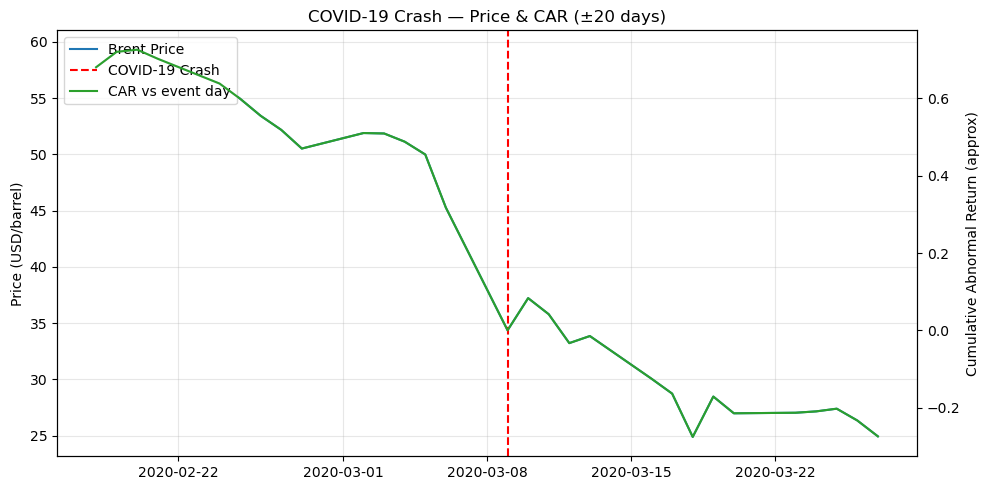

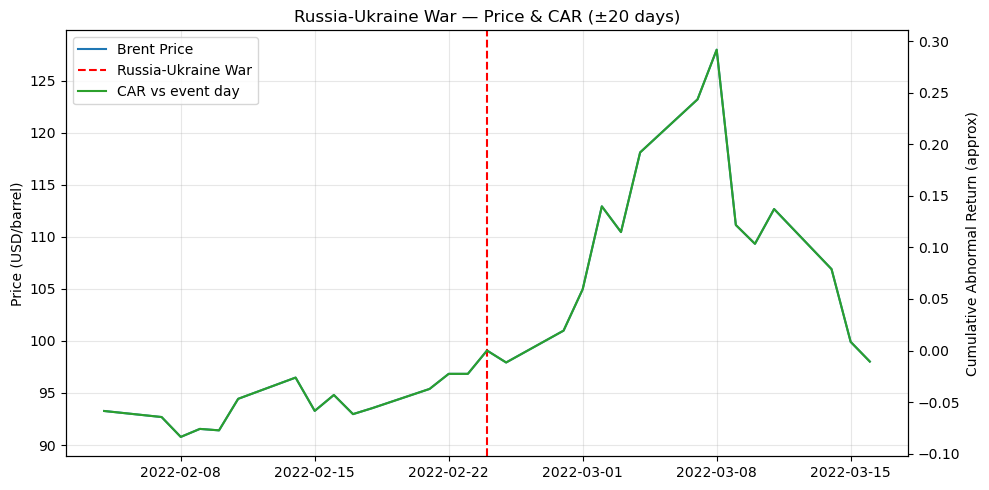

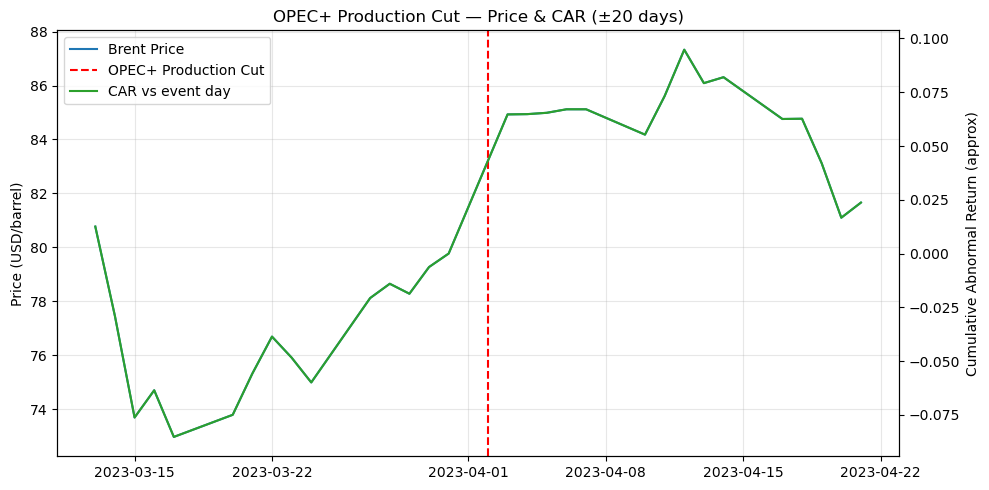

,Event,Date,"CAR [-10, -1]","CAR [+1, +10]",Volatility pre (σ),Volatility post (σ)
0,COVID-19 Crash,2020-03-09,-13.24%,-17.14%,4.07%,9.58%
1,Russia-Ukraine War,2022-02-24,+2.54%,+19.21%,1.99%,4.04%
2,OPEC+ Production Cut,2023-04-02,+4.02%,+9.48%,1.84%,2.37%


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 0) Load and robustly parse Date
# ---------------------------
df = pd.read_excel("cleaned data.xlsx")


df.rename(columns={df.columns[0]: "Date"}, inplace=True)


df.columns = df.columns.str.strip()

# Try robust date parsing:
# - If values are numbers (Excel serial dates), convert with origin
# - Else, try to_datetime with coercion
d0 = df['Date']

if np.issubdtype(d0.dtype, np.number):
    # Excel serial dates
    df['Date'] = pd.to_datetime(d0, origin='1899-12-30', unit='D', errors='coerce')
else:
    # Remove obvious junk/whitespace
    d0 = d0.astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)
    # First broad pass
    d1 = pd.to_datetime(d0, errors='coerce', infer_datetime_format=True)
    # If many NaT remain, try a common alternative (dayfirst):
    if d1.isna().mean() > 0.2:
        d1_alt = pd.to_datetime(d0, errors='coerce', dayfirst=True)
        # Use whichever parsed more rows
        d1 = d1 if d1.isna().mean() <= d1_alt.isna().mean() else d1_alt
    df['Date'] = d1

# Drop rows with unparsed dates & sort
bad_dates = df['Date'].isna().sum()
if bad_dates:
    print(f"[Info] Dropping {bad_dates} rows with unparseable dates.")
df = df.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)
df = df.set_index('Date')

# ---------------------------
# 1) Pick a Brent price column and build returns
# ---------------------------
# Try the most likely headers in your file
candidates_brent = ['CO1 Comdty', 'Brent', 'Brent (CO1)']
brent_col = next((c for c in candidates_brent if c in df.columns), None)
assert brent_col is not None, f"Could not find a Brent price column. Saw: {df.columns.tolist()}"

# Ensure numeric
df[brent_col] = pd.to_numeric(df[brent_col], errors='coerce')

# Build canonical price/return columns for plotting
df['Price']   = df[brent_col]
df['Returns'] = df['Price'].pct_change()

# Final clean
df = df.dropna(subset=['Price'])

# ---------------------------
# 2) Event list (you can add/adjust)
# ---------------------------
events = {
    "COVID-19 Crash": "2020-03-09",         # global oil crash
    "Russia-Ukraine War": "2022-02-24",     # invasion date
    "OPEC+ Production Cut": "2023-04-02"    # example OPEC+ weekend cut
}

# ---------------------------
# 3) Helpers: plot window & summary metrics
# ---------------------------
def plot_event_window(event_name, event_date, window=20):
    t0 = pd.to_datetime(event_date)
    start, end = t0 - pd.Timedelta(days=window), t0 + pd.Timedelta(days=window)
    w = df.loc[start:end].copy()

    # Cumulative return (approx CAR). Rebase at event date.
    w['CumRet'] = (1 + w['Returns']).cumprod()
    if t0 in w.index:
        base = w.loc[t0, 'CumRet']
        w['CAR'] = w['CumRet'] / base - 1.0
    else:
        # If event date not a trading day, base on nearest prior date
        prior = w.index[w.index <= t0].max()
        base = w.loc[prior, 'CumRet'] if pd.notna(prior) else w['CumRet'].iloc[0]
        w['CAR'] = w['CumRet'] / base - 1.0

    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(w.index, w['Price'], color='tab:blue', label='Brent Price')
    ax1.axvline(t0, color='red', ls='--', lw=1.5, label=f'{event_name}')
    ax1.set_ylabel("Price (USD/barrel)")
    ax1.set_title(f"{event_name} — Price & CAR (±{window} days)")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(w.index, w['CAR'], color='tab:green', label='CAR vs event day')
    ax2.set_ylabel("Cumulative Abnormal Return (approx)")

    # Combined legend
    lines, labels = [], []
    for ax in (ax1, ax2):
        l, lab = ax.get_legend_handles_labels()
        lines += l; labels += lab
    ax1.legend(lines, labels, loc='upper left')

    plt.tight_layout()
    plt.show()

def event_summary(event_date, pre=10, post=10):
    """Compute CAR and volatility (std of returns) pre/post event."""
    t0 = pd.to_datetime(event_date)
    pre_win  = df.loc[t0 - pd.Timedelta(days=pre): t0 - pd.Timedelta(days=1)]
    post_win = df.loc[t0 + pd.Timedelta(days=1): t0 + pd.Timedelta(days=post)]

    car_post = (1 + post_win['Returns']).prod() - 1 if not post_win.empty else np.nan
    car_pre  = (1 + pre_win['Returns']).prod() - 1  if not pre_win.empty else np.nan

    vol_pre  = pre_win['Returns'].std()  if not pre_win.empty else np.nan
    vol_post = post_win['Returns'].std() if not post_win.empty else np.nan

    return car_pre, car_post, vol_pre, vol_post

# ---------------------------
# 4) Run: plots + summary table
# ---------------------------
summary_rows = []
for ev, dt in events.items():
    plot_event_window(ev, dt, window=20)
    car_pre, car_post, vol_pre, vol_post = event_summary(dt, pre=10, post=10)
    summary_rows.append({
        "Event": ev,
        "Date": pd.to_datetime(dt).date(),
        "CAR [-10, -1]": car_pre,
        "CAR [+1, +10]": car_post,
        "Volatility pre (σ)": vol_pre,
        "Volatility post (σ)": vol_post
    })

summary = pd.DataFrame(summary_rows)
# Format nicely for display
display(summary.style.format({
    "CAR [-10, -1]": "{:+.2%}",
    "CAR [+1, +10]": "{:+.2%}",
    "Volatility pre (σ)": "{:.2%}",
    "Volatility post (σ)": "{:.2%}"
}))


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True


In [6]:
# === CONFIG ===
FILE = "cleaned data.xlsx"          # <== change if needed
OUT  = Path("./figs"); OUT.mkdir(exist_ok=True)

# Read Excel
df_raw = pd.read_excel(FILE)

# Rename first column to 'Date' if unnamed
if df_raw.columns[0] != "Date":
    df_raw = df_raw.rename(columns={df_raw.columns[0]: "Date"})

# Strip header whitespace
df_raw.columns = df_raw.columns.str.strip()

# Robust date parsing: handle strings and Excel serials
d0 = df_raw["Date"]
if np.issubdtype(d0.dtype, np.number):
    df_raw["Date"] = pd.to_datetime(d0, origin="1899-12-30", unit="D", errors="coerce")
else:
    s = d0.astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
    d1 = pd.to_datetime(s, errors="coerce", infer_datetime_format=True)
    if d1.isna().mean() > 0.2:
        d1_alt = pd.to_datetime(s, errors="coerce", dayfirst=True)
        d1 = d1 if d1.isna().mean() <= d1_alt.isna().mean() else d1_alt
    df_raw["Date"] = d1

# Drop bad dates, sort, index
df = (df_raw
      .dropna(subset=["Date"])
      .sort_values("Date")
      .set_index("Date"))

# Make everything else numeric (errors -> NaN kept)
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Columns:", list(df.columns))
df.head()


Columns: ['DAL US Equity', 'Unnamed: 2', 'AAL US Equity', 'Unnamed: 4', 'RYA ID Equity', 'Unnamed: 6', 'Unnamed: 7', 'LHA GR Equity', 'Unnamed: 9', 'Unnamed: 10', 'SIA SP Equity', 'Unnamed: 12', 'Unnamed: 13', 'QAN AU Equity', 'Unnamed: 15', 'Unnamed: 16', 'IAG LN Equity', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'CO1 Comdty', 'CL1 Comdty', 'WT1 Comdty', 'Unnamed: 24', 'Unnamed: 25', 'EURUSD Curncy', 'GBPUSD Curncy', 'AUDUSD Curncy', 'SGDUSD Curncy']


C:\Users\POOJA\AppData\Local\Temp\ipykernel_34852\1472418198.py:21: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  d1 = pd.to_datetime(s, errors="coerce", infer_datetime_format=True)
C:\Users\POOJA\AppData\Local\Temp\ipykernel_34852\1472418198.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  d1 = pd.to_datetime(s, errors="coerce", infer_datetime_format=True)


,DAL US Equity,Unnamed: 2,AAL US Equity,Unnamed: 4,RYA ID Equity,Unnamed: 6,Unnamed: 7,LHA GR Equity,Unnamed: 9,Unnamed: 10,...,Unnamed: 20,CO1 Comdty,CL1 Comdty,WT1 Comdty,Unnamed: 24,Unnamed: 25,EURUSD Curncy,GBPUSD Curncy,AUDUSD Curncy,SGDUSD Curncy
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,56.00,0.0000,52.03,0.0000,15.050,0.0000,18.078060,21.924,0.0272,26.335109,...,NaN,66.87,60.42,54.21,NaN,NaN,1.2012,1.3503,0.7805,0.7478
2018-01-02,56.74,0.0000,52.99,0.0000,15.045,-0.6321,18.142765,21.557,-0.3402,25.995586,...,NaN,66.57,60.37,56.15,NaN,NaN,1.2059,1.3590,0.7830,0.7523
2018-01-03,55.69,-0.1012,52.34,-0.0002,15.360,0.0167,18.455040,22.031,-0.0566,26.470246,...,NaN,67.84,61.63,56.69,NaN,NaN,1.2015,1.3516,0.7836,0.7521
2018-01-04,55.69,-0.0851,52.67,-0.0005,15.360,0.0011,18.536448,21.910,0.0000,26.440988,...,NaN,68.07,62.01,56.61,NaN,NaN,1.2068,1.3551,0.7864,0.7532
2018-01-05,55.97,-0.0024,52.65,-0.0003,15.270,0.0061,18.368283,21.339,0.0000,25.668683,...,NaN,67.62,61.44,56.18,NaN,NaN,1.2029,1.3571,0.7864,0.7538


In [8]:
# Candidate names (use what you actually have)
oil_candidates = [
    "CO1 Comdty", "Brent", "Brent (CO1)", 
    "CL1 Comdty", "WTI", "WTI Comdty", "WT1 Comdty"
]

airline_candidates = {
    "AAL": ["AAL US Equity", "AAL"],
    "DAL": ["DAL US Equity", "DAL"],
    "LHA": ["LHA GR Equity", "LHA"],
    "RYA": ["RYA ID Equity", "RYA"],
    "SIA": ["SIA SP Equity", "SIA"],
    "QAN": ["QAN AU Equity", "QAN"]
}

# Find present oil columns
oil_cols = [c for c in oil_candidates if c in df.columns]
assert len(oil_cols) >= 1, f"No oil columns found. Saw: {df.columns.tolist()}"
print("Oil columns found:", oil_cols)

# Map airline tickers to the actual present column names
air_cols_map = {}
for tag, options in airline_candidates.items():
    for col in options:
        if col in df.columns:
            air_cols_map[tag] = col
            break

air_cols = list(air_cols_map.values())
assert len(air_cols) >= 1, "No airline columns found. Please check your column names."
print("Airline columns found:", air_cols_map)


Oil columns found: ['CO1 Comdty', 'CL1 Comdty', 'WT1 Comdty']
Airline columns found: {'AAL': 'AAL US Equity', 'DAL': 'DAL US Equity', 'LHA': 'LHA GR Equity', 'RYA': 'RYA ID Equity', 'SIA': 'SIA SP Equity', 'QAN': 'QAN AU Equity'}


In [11]:
# Use month-end last price (avoid averaging prices)
monthly = df[[*oil_cols, *air_cols]].resample("M").last()

# Returns
ret_m = monthly.pct_change()

# Equal-weight airline basket (for 7.2 & 7.3)
ret_m["AIR_EQW"] = ret_m[air_cols].mean(axis=1)

# Helper to build cum-index rebased to 100
def rebased_index(returns, base=100.0):
    idx = (1 + returns.fillna(0)).cumprod()
    return base * idx

monthly.head(), ret_m.head()


C:\Users\POOJA\AppData\Local\Temp\ipykernel_34852\1544704286.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df[[*oil_cols, *air_cols]].resample("M").last()


(            CO1 Comdty  CL1 Comdty  WT1 Comdty  AAL US Equity  DAL US Equity  \
 Date                                                                           
 2018-01-31       69.05       64.73       56.80          54.32          56.77   
 2018-02-28       65.78       61.64       54.14          54.25          53.90   
 2018-03-31       70.27       64.94       54.37          51.96          54.81   
 2018-04-30       75.17       68.57       57.51          42.93          52.22   
 2018-05-31       77.59       67.04       64.96          43.54          54.05   
 
             LHA GR Equity  RYA ID Equity  SIA SP Equity  QAN AU Equity  
 Date                                                                    
 2018-01-31         20.411         16.670          7.969           5.27  
 2018-02-28         19.576         16.200          7.814           5.89  
 2018-03-31         18.556         16.000          7.638           5.83  
 2018-04-30         17.214         15.510          7.666     